# Procedimiento

In [1]:
import zipfile
import os
import shutil

zip_file_path = '/content/fruits_dataset_balanced.zip'
extraction_path = '/content/fruits_dataset'

# Remove the file path if exists
if os.path.exists(extraction_path):
    shutil.rmtree(extraction_path)
    print(f"Existing directory '{extraction_path}' deleted.")
os.makedirs(extraction_path, exist_ok=True)

# Unzip the ZIP file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Extracted files to: {extraction_path}")

Extracted files to: /content/fruits_dataset


In [2]:
# Import all the libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import models
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [3]:
# Define paths for the dataset and its subsets
DATASET_PATH = "/content/fruits_dataset"
TRAINING_PATH = DATASET_PATH + "/Training"
TEST_PATH = DATASET_PATH + "/Test"
VALIDATION_PATH = DATASET_PATH + "/Validation"

In [4]:
# Define parameters
EPOCHS = 10
classes = os.listdir(TRAINING_PATH)
INPUT_SHAPE = (100, 100, 3)

## Hiperparametros utilizados

In [5]:
# Define hyperparameters for model training
BATCH_SIZE = 64
OPTIMIZER = 'adam'
LOSS = 'categorical_crossentropy'
METRICS = ['accuracy']
LEARNING_RATE = 0.001

In [6]:
datagen = ImageDataGenerator(rescale=1.0/255.0)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

# Training data
print("Loading Training data...")
train_generator = train_datagen.flow_from_directory(
    TRAINING_PATH,
    target_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Validation data
print("Loading Validation data...")
val_generator = datagen.flow_from_directory(
    VALIDATION_PATH,
    target_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Test data
print("Loading Test data...")
test_generator = datagen.flow_from_directory(
    TEST_PATH,
    target_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Loading Training data...
Found 5740 images belonging to 10 classes.
Loading Validation data...
Found 820 images belonging to 10 classes.
Loading Test data...
Found 1650 images belonging to 10 classes.


# Modelo
Modelo obtenido de: Alrashdi, I., Sharawi, M., Ali, A.M. et al. Utilizing deep learning models for early detection and classification of fruit diseases: towards sustainable agriculture and enhanced food quality. Sci Rep 16, 8167 (2026). https://doi.org/10.1038/s41598-026-38259-3

In [7]:
def get_model(input_shape, num_classes):
    """
    Builds the CNN architecture with convolutional and pooling layers, followed by dense layers.
    This model architecture is inspired by the paper: Alrashdi, I., Sharawi, M., Ali, A.M. et al.
    Utilizing deep learning models for early detection and classification of fruit diseases: towards
    sustainable agriculture and enhanced food quality. Sci Rep 16, 8167 (2026). https://doi.org/10.1038/s41598-026-38259-3.

    Args:
        input_shape (tuple): The shape of the input images (height, width, channels).
        num_classes (int): The number of output classes for the softmax layer.

    Returns:
        keras.Model: The compiled Keras model.
    """
    model = Sequential([
        # Extractor
        # Conv 3*3 + ReLU
        Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape, name='Conv_1'),
        # Max pooling
        MaxPooling2D(pool_size=(2, 2), name='MaxPool_1'),

        # Conv 3*3 + ReLU
        Conv2D(64, kernel_size=(3, 3), activation='relu', name='Conv_2'),
        # Max pooling
        MaxPooling2D(pool_size=(2, 2), name='MaxPool_2'),

        # Flatten
        Flatten(name='Flatten_Layer'),

        # Classifier
        # Dense 128 + ReLU
        Dense(128, activation='relu', name='Dense_128'),
        # Dense 64 + ReLU
        Dense(64, activation='relu', name='Dense_64'),
        # Dense 32 + ReLU
        Dense(32, activation='relu', name='Dense_32'),
        # Dense 16 + Softmax
        Dense(num_classes, activation='softmax', name='Output_Softmax')
    ])

    return model

In [8]:
# Build and display the model summary
model = get_model(INPUT_SHAPE, len(classes))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_1 (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten_Layer (Flatten)         │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_128 (Dense)               │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Softmax (Dense)          │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,363,754 (16.65 MB)

 Trainable params: 4,363,754 (16.65 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del modelo

In [9]:
def compile_model(model, opt):
    """
    Compiles the Keras model with a specified optimizer, loss function, and metrics.

    Args:
        model (keras.Model): The Keras model to compile.
        opt (keras.optimizers.Optimizer): The optimizer to use for training.

    Returns:
        None
    """
    if opt is not None:
        model.compile(
            optimizer=opt,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    else:
        print("Error: Optimizer not specified.")

In [10]:
def train_model(model, train_generator, validation_generator, epochs):
    """
    Trains the given Keras model using image data generators for training and validation.

    Args:
        model (keras.Model): The Keras model to train.
        train_generator (ImageDataGenerator): Generator for training data.
        validation_generator (ImageDataGenerator): Generator for validation data.
        epochs (int): The number of epochs to train the model.

    Returns:
        keras.callbacks.History: A History object containing training loss and metrics.
    """
    history = model.fit(
        train_generator,
        steps_per_epoch=100,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=50,
    )
    return history

In [11]:
opt = None
if OPTIMIZER == 'adam':
    # Initialize Adam optimizer with a specified learning rate
    opt = optimizers.Adam(learning_rate=LEARNING_RATE)

compile_model(model, opt)
history = train_model(model, train_generator, val_generator, EPOCHS)

Epoch 1/10
 90/100 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2031 - loss: 2.1451

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.2843 - loss: 1.9479 - val_accuracy: 0.4293 - val_loss: 1.6317
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.4498 - loss: 1.5486 - val_accuracy: 0.4976 - val_loss: 1.3598
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.5033 - loss: 1.4233 - val_accuracy: 0.5195 - val_loss: 1.3298
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.5261 - loss: 1.3416 - val_accuracy: 0.5671 - val_loss: 1.2721
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.5702 - loss: 1.2283 - val_accuracy: 0.6110 - val_loss: 1.1294
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.6009 - loss: 1.1557 - val_accuracy: 0.5976 - val_loss: 1.2492
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.6237 - loss: 1.0797 - val_accuracy: 0.6354 - val_loss: 1.1657
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.6376 - loss: 1.0491 - val_accuracy: 0.645

### Gráfica de accuracy y loss para training y validation

In [12]:
def plot_learning_curves(history, epochs):
    """
    Generates performance graphs (Accuracy and Loss) for the training
    and validation stages based on Keras history.

    Args:
        history (keras.callbacks.History): The history object returned from model.fit().
        epochs (int): The number of epochs the model was trained for.

    Returns:
        None: Displays the plots.
    """
    # Extract metrics from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Create a vector with the number of epochs (1 to N)
    epochs_range = range(1, epochs + 1)

    # Configure the canvas to put two plots together (1 row, 2 columns)
    plt.figure(figsize=(14, 5))

    # PLOT 1: TRAIN VS VALIDATION ACCURACY
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2)
    plt.title('Training and Validation Accuracy', fontsize=14, pad=12)
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5) # Subtle background grid

    # PLOT 2: TRAIN VS VALIDATION LOSS
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=14, pad=12)
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Loss', fontsize=11)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5) # Subtle background grid

    # Adjust spacing and save the image for your report
    plt.tight_layout()
    plt.savefig('curvas_aprendizaje_frutas.png', dpi=300)
    plt.show()

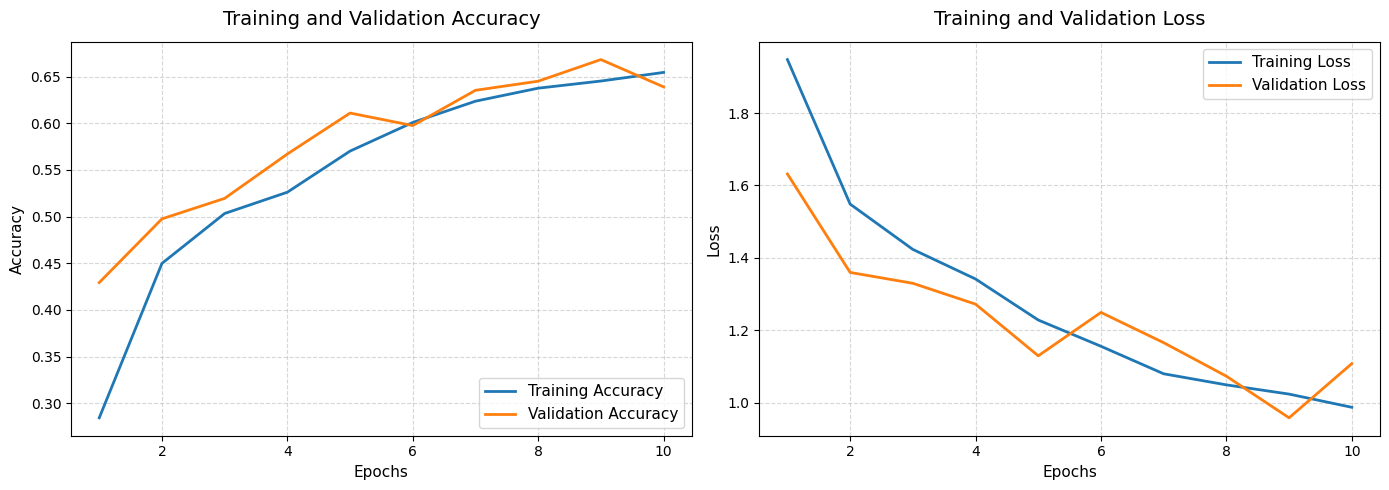

In [13]:
plot_learning_curves(history, EPOCHS)

## Testing del modelo

In [14]:
def evaluate_model(model, test_generator):
    """
    Evaluates the trained Keras model on the test dataset.

    Args:
        model (keras.Model): The trained Keras model.
        test_generator (ImageDataGenerator): Generator for test data.

    Returns:
        tuple: A tuple containing (test_loss, test_accuracy).
    """
    test_loss, test_accuracy = model.evaluate(test_generator)
    return (test_loss, test_accuracy)

In [15]:
# Evaluate the model using the test_generator
test_loss, test_accuracy = evaluate_model(model, test_generator)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 336ms/step - accuracy: 0.6455 - loss: 1.1158

Test Loss: 1.1158
Test Accuracy: 0.6455


### Gráfica de comparación training vs validation vs loss

In [16]:
def plot_final_accuracy_comparison(history, test_accuracy):
    """
    Generates a bar plot to compare the final Accuracy
    of the three stages: Training, Validation, and Test.

    Args:
        history (keras.callbacks.History): The history object returned from model.fit().
        test_accuracy (float): The accuracy obtained on the test set.

    Returns:
        None: Displays the plot.
    """
    # Extract the last value of training and validation
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    # Plot data
    stages = ['Training', 'Validation', 'Test']
    vals = [final_train_acc, final_val_acc, test_accuracy]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    plt.figure(figsize=(8, 4))
    barras = plt.bar(stages, vals, color=colors, width=0.5, edgecolor='black', alpha=0.8)

    # Add exact numbers above each bar
    for barra in barras:
        alto = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width()/2,
            alto + 0.05,
            f'{alto:.2f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # Plot aesthetics
    plt.title('Accuracy of all the stages', fontsize=14, pad=20, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.15) # Space upwards so text is not cut off
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Save in high quality for your methodological framework
    plt.tight_layout()
    plt.savefig('comparative_accuracy.png', dpi=300)
    plt.show()

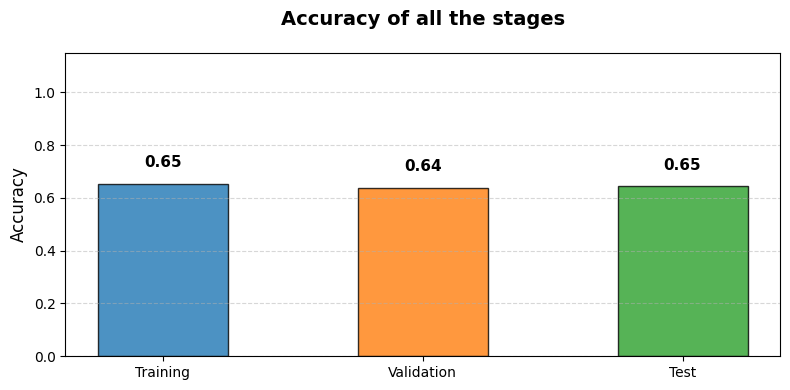

In [17]:
plot_final_accuracy_comparison(history, test_accuracy)

## Predecir frutas aleatorias

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


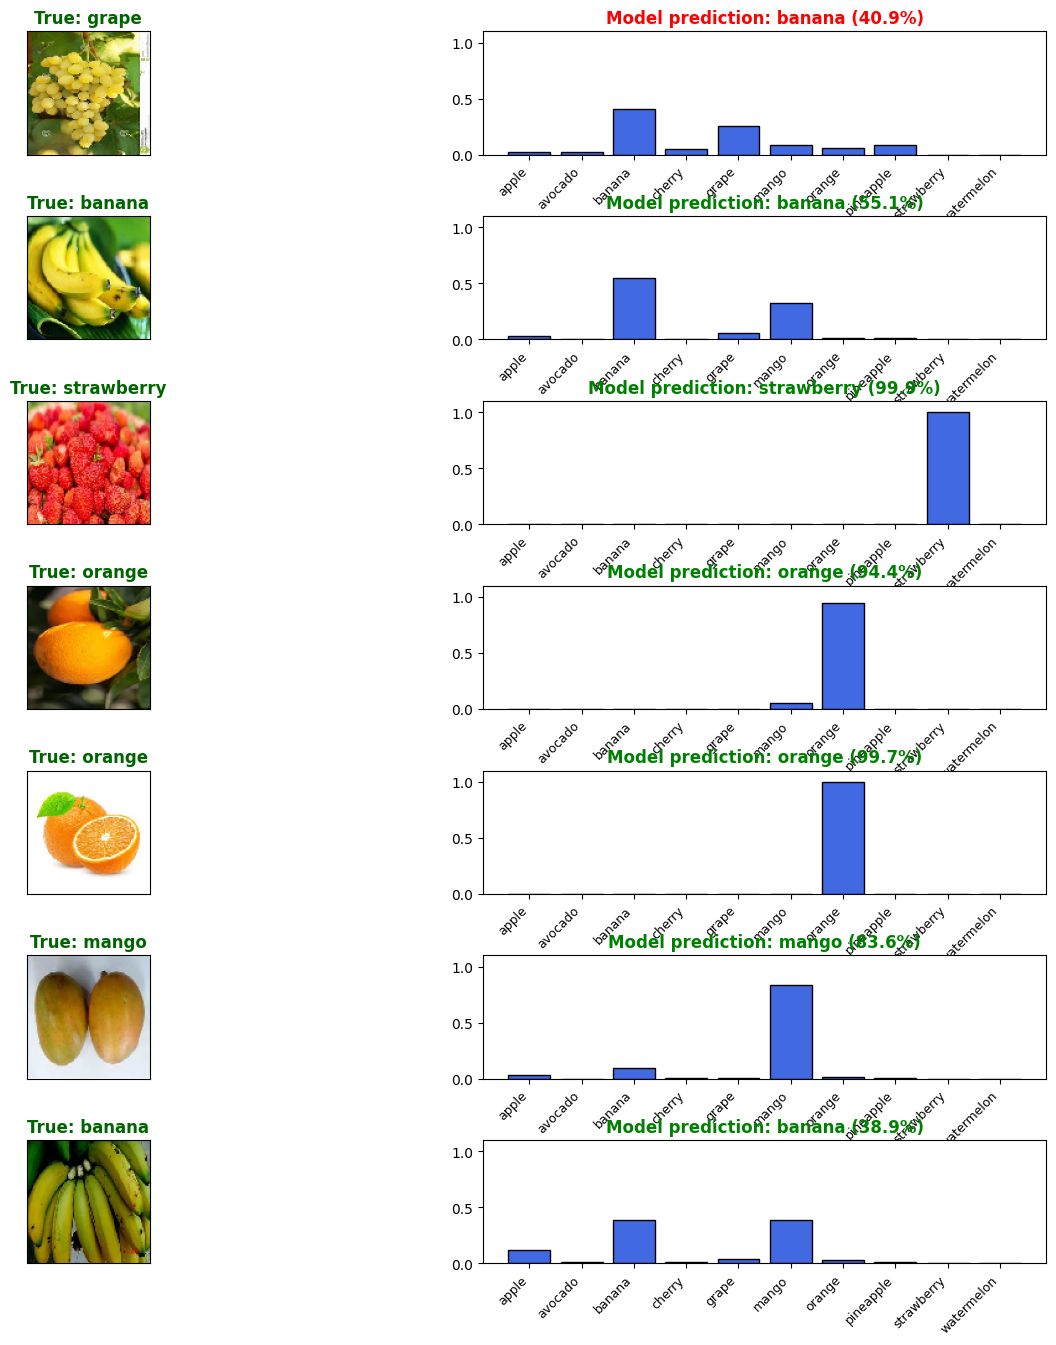

In [18]:
# Extract the names of the classes
class_names = list(test_generator.class_indices.keys())

# Random selection
random_test_images = []
random_test_labels = []
num_total_batches = len(test_generator)

# We are going to jump to 4 different random batches throughout the dataset
for _ in range(7):
    # Choose a random batch
    random_batch_idx = np.random.randint(0, num_total_batches)
    x_batch, y_batch = test_generator[random_batch_idx]

    # Choose a random image from that batch
    random_img_idx = np.random.randint(0, len(x_batch))

    random_test_images.append(x_batch[random_img_idx])
    random_test_labels.append(y_batch[random_img_idx])

# Convert lists into NumPy arrays
random_test_images = np.array(random_test_images)
random_test_labels = np.array(random_test_labels)

# The model predict
predictions = model.predict(random_test_images)

# Configure the visualization canvas
fig, axes = plt.subplots(7, 2, figsize=(16, 16))
fig.subplots_adjust(hspace=0.5, wspace=0.2)

for i, (prediction, image, label) in enumerate(zip(predictions, random_test_images, random_test_labels)):
    # Real image
    axes[i, 0].imshow(image)
    axes[i, 0].get_xaxis().set_visible(False)
    axes[i, 0].get_yaxis().set_visible(False)

    true_class_idx = np.argmax(label)
    #true_class_name = true_class_idx
    true_class_name = class_names[true_class_idx]
    axes[i, 0].set_title(f'True: {true_class_name}', fontsize=12, color='darkgreen', fontweight='bold')

    # Categorical distribution
    axes[i, 1].bar(np.arange(len(prediction)), prediction, color='royalblue', edgecolor='black')
    axes[i, 1].set_xticks(np.arange(len(prediction)))
    axes[i, 1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    axes[i, 1].set_ylim(0, 1.1)

    pred_class_idx = np.argmax(prediction)
    pred_class_name = class_names[pred_class_idx]
    confidence_score = prediction[pred_class_idx] * 100

    title_color = 'green' if pred_class_idx == true_class_idx else 'red'

    axes[i, 1].set_title(
        f"Model prediction: {pred_class_name} ({confidence_score:.1f}%)",
        color=title_color,
        fontweight='bold'
    )

plt.show()

In [19]:
def predict_model_data(model, test_generator):
    """
    Makes predictions using the trained model on the test generator and extracts true and predicted labels.

    Args:
        model (keras.Model): The trained Keras model.
        test_generator (ImageDataGenerator): Generator for test data.

    Returns:
        tuple: A tuple containing (y_true, y_pred).
               y_true (np.array): True labels.
               y_pred (np.array): Predicted labels.
    """
    predictions = model.predict(test_generator, verbose=1)

    # Convert probabilities to the index of the class with the highest value
    y_pred = np.argmax(predictions, axis=1)

    # Get true labels and category names directly from the generator
    y_true = test_generator.classes
    return (y_true, y_pred)

In [20]:
def plot_global_binary_confusion_matrix(y_true, y_pred):
    """
    Calculates and plots the global confusion matrix (2x2) oriented with
    Positives in the first row/column and Negatives in the second (image order 1).

    Args:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted labels.

    Returns:
        None: Displays the plot.
    """
    # Get individual matrices for each of the classes
    mcm = multilabel_confusion_matrix(y_true, y_pred)

    tn = mcm[:, 0, 0].sum()
    fp = mcm[:, 0, 1].sum()
    fn = mcm[:, 1, 0].sum()
    tp = mcm[:, 1, 1].sum()

    global_cm = np.array([[tp, fn],
                          [fp, tn]])

    # Create dynamic texts
    labels = np.array([
        [f"True positives\n{tp:,}", f"False negatives\n{fn:,}"],
        [f"False positives\n{fp:,}", f"True negatives\n{tn:,}"]
    ])

    # Design the plot with axis names
    plt.figure(figsize=(8, 7))
    sns.heatmap(
        global_cm,
        annot=labels,
        fmt="",
        cmap="Blues",
        cbar=True,
        xticklabels=["Predicted Positive", "Predicted Negative"],
        yticklabels=["Actually Positive", "Actually Negative"]
    )

    # Title and axis aesthetics
    plt.title("General confusion matrix", fontsize=14, pad=20, fontweight='bold')
    plt.ylabel("Actual Label", fontsize=12, labelpad=10)
    plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
    plt.tight_layout()

    plt.savefig('matrix_confusion_global.png', dpi=300)
    plt.show()

In [21]:
def plot_custom_confusion_matrix(y_true, y_pred, class_names):
    """
    Calculates and visually plots the confusion matrix for multiclass classification.

    Args:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted labels.
        class_names (list): List of class names.

    Returns:
        None: Displays the plot.
    """
    cm = confusion_matrix(y_true, y_pred)

    # Configure the plot
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    # Plot configurations
    plt.title('Confusion Matrix - Fruit Classification', fontsize=16, pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    plt.savefig('confusion_matrix_classes.png', dpi=300)
    plt.show()

In [22]:
y_true, y_pred = predict_model_data(model, test_generator)

26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 320ms/step


## Matriz de confusión general

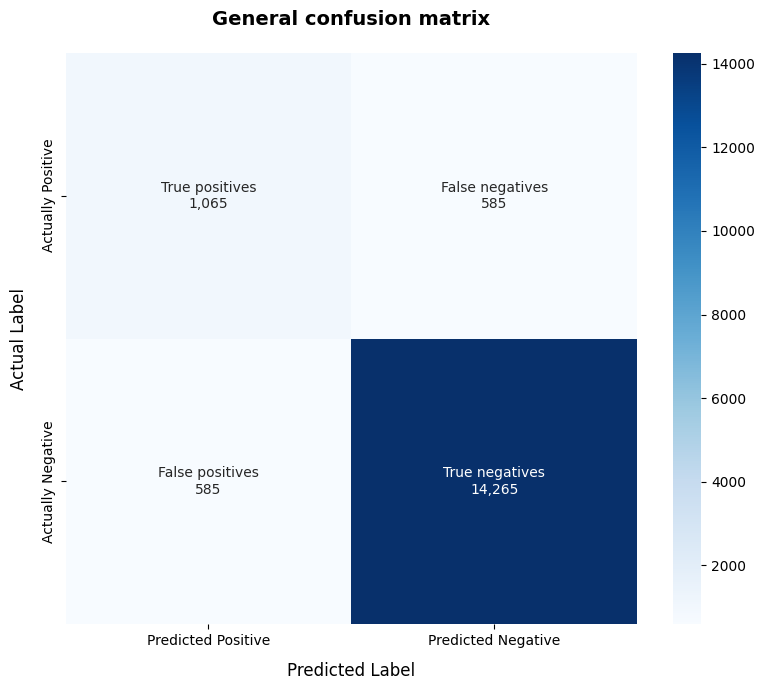

In [23]:
plot_global_binary_confusion_matrix(y_true, y_pred)

In [24]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='micro')
recall = recall_score(y_true, y_pred, average='micro')
f1 = f1_score(y_true, y_pred, average='micro')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.6454545454545455
Precision: 0.6454545454545455
Recall: 0.6454545454545455
F1 Score: 0.6454545454545455


## Matriz de confusión por clases

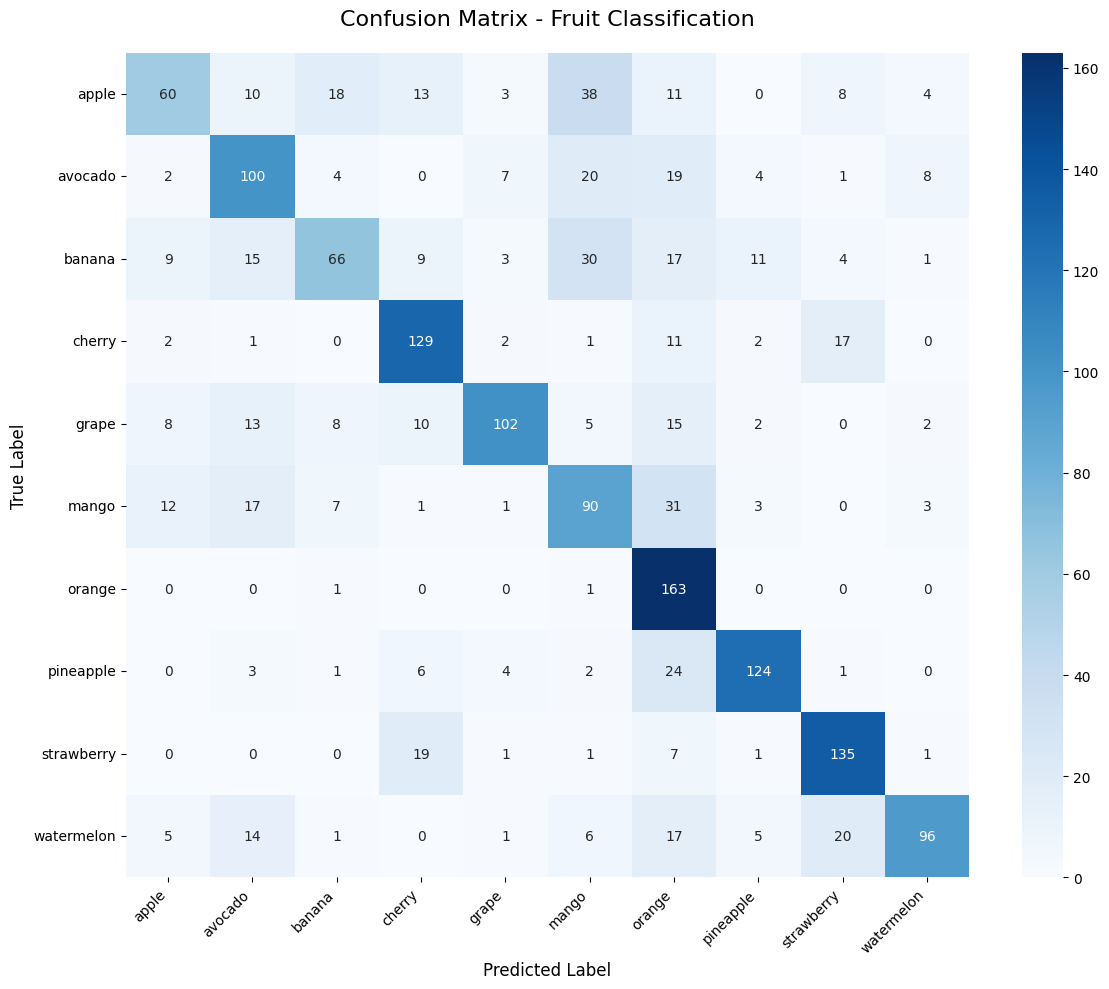

In [25]:
plot_custom_confusion_matrix(y_true, y_pred, class_names)

In [26]:
model.save('model.keras')